# Phase 5B — Graph-Based Models

This notebook implements the graph-based modeling stage of the thesis.

The goal is to predict whether a user will re-engage with the same streamer within a 3-day horizon (432 timesteps) using a leakage-safe graph representation of historical user–streamer interactions.

This phase follows the same temporal split and evaluation protocol used in Phase 5A in order to ensure a fair comparison between traditional and graph-based approaches.

The notebook starts by loading the anchor-level modeling dataset and preparing the environment for graph construction and model development.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Evaluation
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paths used at initialization
ANCHOR_DATA_PATH = Path("../data_processed/model_dataset_100k_3day.csv")

REPORTS_FIG_PATH = Path("../reports/modeling/figures")
REPORTS_TABLE_PATH = Path("../reports/modeling/tables")

REPORTS_FIG_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_TABLE_PATH.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print("Anchor dataset path exists:", ANCHOR_DATA_PATH.exists())
print("Torch version:", torch.__version__)

Setup complete.
Anchor dataset path exists: True
Torch version: 2.10.0+cpu


## Anchor Dataset Initialization and Split Integrity Checks

In this step, the anchor-level modeling dataset is loaded and inspected before graph construction.

The purpose is to:

- verify dataset shape and column structure
- confirm the predefined train / validation / test segmentation
- inspect label balance across segments
- prepare for the analysis of unseen users, streamers, and user–streamer pairs across temporal splits

These checks are important because the suitability of a graph-based model depends not only on predictive performance, but also on whether validation and test instances contain nodes or pairs that were not observed during training.

In [32]:
# Load anchor-level dataset
df = pd.read_csv(ANCHOR_DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSegment distribution:")
print(df["segment"].value_counts())

print("\nOverall label distribution:")
print(df["label"].value_counts(normalize=True))

print("\nLabel rate by segment:")
print(df.groupby("segment")["label"].mean())

Dataset shape: (2380571, 8)


,user_id,streamer_name,stream_id,prediction_time,duration_intervals,duration_minutes,segment,label
0,1,alptv,33846768288,166,3,30,train,0
1,1,berkriptepe,33903958784,734,3,30,train,0
2,1,elraenn,34079135968,2600,1,10,train,0
3,1,elraenn,34236660832,4314,1,10,validation,0
4,1,esl_csgo,34328509984,5208,1,10,test,0



Columns:
['user_id', 'streamer_name', 'stream_id', 'prediction_time', 'duration_intervals', 'duration_minutes', 'segment', 'label']

Missing values by column:
user_id               0
streamer_name         0
stream_id             0
prediction_time       0
duration_intervals    0
duration_minutes      0
segment               0
label                 0
dtype: int64

Duplicate rows: 0

Segment distribution:
segment
train         1373160
validation     520761
test           486650
Name: count, dtype: int64

Overall label distribution:
label
0    0.772046
1    0.227954
Name: proportion, dtype: float64

Label rate by segment:
segment
test          0.239721
train         0.219275
validation    0.239843
Name: label, dtype: float64


## Unseen Node and Pair Analysis Across Temporal Splits

Before selecting the graph-based model, it is necessary to measure how much of the validation and test data consists of entities that were not observed during training.

Three quantities are especially important:

- unseen users
- unseen streamers
- unseen user–streamer pairs

If validation and test instances mostly involve users and streamers already present in the training graph, a transductive graph model such as LightGCN can be used as a defensible baseline.

If unseen nodes are frequent, an inductive model such as GraphSAGE may be more appropriate.

In [33]:
# Split data
train_df = df[df["segment"] == "train"].copy()
val_df = df[df["segment"] == "validation"].copy()
test_df = df[df["segment"] == "test"].copy()

# Training reference sets
train_users = set(train_df["user_id"].unique())
train_streamers = set(train_df["streamer_name"].unique())
train_pairs = set(zip(train_df["user_id"], train_df["streamer_name"]))

def unseen_summary(split_df, split_name):
    total_rows = len(split_df)

    unseen_user_mask = ~split_df["user_id"].isin(train_users)
    unseen_streamer_mask = ~split_df["streamer_name"].isin(train_streamers)
    unseen_pair_mask = ~split_df.apply(
        lambda row: (row["user_id"], row["streamer_name"]) in train_pairs,
        axis=1
    )

    summary = {
        "split": split_name,
        "rows": total_rows,
        "unseen_users_count": unseen_user_mask.sum(),
        "unseen_users_rate": unseen_user_mask.mean(),
        "unseen_streamers_count": unseen_streamer_mask.sum(),
        "unseen_streamers_rate": unseen_streamer_mask.mean(),
        "unseen_pairs_count": unseen_pair_mask.sum(),
        "unseen_pairs_rate": unseen_pair_mask.mean(),
    }
    return pd.Series(summary)

unseen_results = pd.DataFrame([
    unseen_summary(val_df, "validation"),
    unseen_summary(test_df, "test")
])

display(unseen_results)

,split,rows,unseen_users_count,unseen_users_rate,unseen_streamers_count,unseen_streamers_rate,unseen_pairs_count,unseen_pairs_rate
0,validation,520761,27542,0.052888,37624,0.072248,268382,0.515365
1,test,486650,41080,0.084414,49099,0.100892,283739,0.583045


### Interpretation of Unseen Node and Pair Analysis

The validation and test sets contain a relatively small proportion of unseen users and streamers. In the test set, approximately 8.4% of users and 10.1% of streamers were not observed in the training segment.

This indicates that most nodes required for validation and test prediction are already present in the training graph. Therefore, a transductive graph-based model such as LightGCN remains methodologically appropriate as a baseline.

In contrast, unseen user–streamer pairs are much more common, covering approximately 51.5% of validation pairs and 58.3% of test pairs. This is expected in a recommendation-style link prediction task: the model is not expected to memorize previously observed pairs, but to generalize from learned user and streamer embeddings to unseen combinations.

Based on these results, Phase 5B proceeds with LightGCN as a static, leakage-safe graph-based baseline trained only on the training interaction graph.

## Loading the Cleaned Interaction Data

The LightGCN graph is constructed from the cleaned interaction-level dataset, `gold_100k.csv`.

This dataset is used because it preserves the historical user–streamer interaction structure required for graph construction. The anchor-level modeling dataset remains responsible for defining prediction instances, labels, and temporal segments.

In [ ]:
# Load cleaned interaction-level dataset for graph construction
GOLD_DATA_PATH = Path("../data_processed/gold_100k.csv")

gold_df = pd.read_csv(GOLD_DATA_PATH)

print("Gold dataset shape:", gold_df.shape)
display(gold_df.head())

print("\nColumns:")
print(gold_df.columns.tolist())

print("\nMissing values:")
print(gold_df.isnull().sum())

print("\nDuplicate rows:", gold_df.duplicated().sum())

Gold dataset shape: (3051733, 7)


,user_id,stream_id,streamer_name,start_time,stop_time,duration_intervals,duration_minutes
0,1,33842865744,mithrain,154,156,2,20
1,1,33846768288,alptv,166,169,3,30
2,1,33886469056,mithrain,587,588,1,10
3,1,33887624992,wtcn,589,591,2,20
4,1,33890145056,jrokezftw,591,594,3,30



Columns:
['user_id', 'stream_id', 'streamer_name', 'start_time', 'stop_time', 'duration_intervals', 'duration_minutes']

Missing values:
user_id               0
stream_id             0
streamer_name         0
start_time            0
stop_time             0
duration_intervals    0
duration_minutes      0
dtype: int64

Duplicate rows: 0


## Leakage-Safe Train Graph Construction

To prevent temporal leakage, the interaction graph is constructed using only interactions that occurred during the training period.

The cutoff time is defined as the maximum prediction timestamp in the training segment. Only interactions with a start time earlier than or equal to this cutoff are included in the graph.

This ensures that the graph represents only the information that would have been available at training time, maintaining consistency with the temporal evaluation setup.

In [35]:
# Get the last available time in training anchors
train_end_time = train_df["prediction_time"].max()

print("Train end time:", train_end_time)

Train end time: 2879


In [36]:
# Filter interactions available during training period
train_graph_df = gold_df[gold_df["start_time"] <= train_end_time].copy()

print("Train graph interactions shape:", train_graph_df.shape)

Train graph interactions shape: (1373160, 7)


In [37]:
# Create bipartite edges (user ↔ streamer)
edges = train_graph_df[["user_id", "streamer_name"]].drop_duplicates()

print("Number of unique edges:", len(edges))
display(edges.head())

Number of unique edges: 842629


,user_id,streamer_name
0,1,mithrain
1,1,alptv
3,1,wtcn
4,1,jrokezftw
5,1,berkriptepe


In [38]:
print("Unique users in graph:", edges["user_id"].nunique())
print("Unique streamers in graph:", edges["streamer_name"].nunique())

Unique users in graph: 90690
Unique streamers in graph: 105055


## Node Indexing and PyTorch Edge Representation

LightGCN requires all graph nodes to be represented as integer indices.

Because the graph is bipartite, users and streamers are first mapped into separate index spaces and then combined into one shared node space:

- users are indexed from `0` to `num_users - 1`
- streamers are indexed from `num_users` onward

The resulting graph is represented as a bidirectional `edge_index` tensor, which allows message passing between users and streamers in both directions.

In [39]:
# Create user and streamer index mappings
unique_users = edges["user_id"].unique()
unique_streamers = edges["streamer_name"].unique()

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
streamer_to_idx = {
    streamer: idx + len(user_to_idx)
    for idx, streamer in enumerate(unique_streamers)
}

num_users = len(user_to_idx)
num_streamers = len(streamer_to_idx)
num_nodes = num_users + num_streamers

print("Number of user nodes:", num_users)
print("Number of streamer nodes:", num_streamers)
print("Total number of nodes:", num_nodes)

Number of user nodes: 90690
Number of streamer nodes: 105055
Total number of nodes: 195745


In [40]:
# Map edges to integer node indices
user_indices = edges["user_id"].map(user_to_idx).values
streamer_indices = edges["streamer_name"].map(streamer_to_idx).values

# Sanity check: no missing mappings
assert pd.isna(user_indices).sum() == 0
assert pd.isna(streamer_indices).sum() == 0

# Convert to tensors
user_indices = torch.tensor(user_indices, dtype=torch.long)
streamer_indices = torch.tensor(streamer_indices, dtype=torch.long)

# Create bidirectional edge_index for message passing
edge_index = torch.stack([
    torch.cat([user_indices, streamer_indices]),
    torch.cat([streamer_indices, user_indices])
], dim=0)

print("edge_index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])
print("Number of unique undirected user-streamer edges:", len(edges))

edge_index shape: torch.Size([2, 1685258])
Number of directed edges: 1685258
Number of unique undirected user-streamer edges: 842629


### Graph Representation Check

The constructed training graph contains 195,745 nodes and 842,629 unique user–streamer edges. For LightGCN message passing, each bipartite edge is represented bidirectionally, resulting in 1,685,258 directed edges in the `edge_index` tensor.

This confirms that the graph was correctly converted into a PyTorch-compatible representation while preserving the user–streamer bipartite structure.

## Preparing Validation and Test Prediction Edges

The LightGCN model can only produce predictions for users and streamers that exist in the training graph.

Therefore, validation and test anchors are mapped to the training graph node index space. Anchors containing unseen users or unseen streamers are excluded from LightGCN evaluation, because no learned embedding is available for those nodes.

This filtering is reported explicitly to make the evaluation transparent.

In [41]:
def prepare_prediction_edges(split_df, split_name):
    split_df = split_df.copy()

    # Keep only anchors where both user and streamer exist in the training graph
    known_mask = (
        split_df["user_id"].isin(user_to_idx) &
        split_df["streamer_name"].isin(streamer_to_idx)
    )

    filtered_df = split_df[known_mask].copy()

    print(f"{split_name} original rows:", len(split_df))
    print(f"{split_name} usable rows:", len(filtered_df))
    print(f"{split_name} excluded rows:", len(split_df) - len(filtered_df))
    print(f"{split_name} usable rate:", round(len(filtered_df) / len(split_df), 4))

    user_idx = filtered_df["user_id"].map(user_to_idx).values
    streamer_idx = filtered_df["streamer_name"].map(streamer_to_idx).values

    edge_label_index = torch.tensor(
        np.vstack([user_idx, streamer_idx]),
        dtype=torch.long
    )

    edge_label = torch.tensor(
        filtered_df["label"].values,
        dtype=torch.float
    )

    return filtered_df, edge_label_index, edge_label

In [42]:
val_graph_df, val_edge_label_index, val_edge_label = prepare_prediction_edges(
    val_df,
    "Validation"
)

test_graph_df, test_edge_label_index, test_edge_label = prepare_prediction_edges(
    test_df,
    "Test"
)

print("\nValidation edge_label_index shape:", val_edge_label_index.shape)
print("Validation labels shape:", val_edge_label.shape)

print("\nTest edge_label_index shape:", test_edge_label_index.shape)
print("Test labels shape:", test_edge_label.shape)

Validation original rows: 520761
Validation usable rows: 459847
Validation excluded rows: 60914
Validation usable rate: 0.883
Test original rows: 486650
Test usable rows: 403830
Test excluded rows: 82820
Test usable rate: 0.8298

Validation edge_label_index shape: torch.Size([2, 459847])
Validation labels shape: torch.Size([459847])

Test edge_label_index shape: torch.Size([2, 403830])
Test labels shape: torch.Size([403830])


### Prediction Edge Coverage

After mapping validation and test anchors to the training graph node space, 88.3% of validation observations and 83.0% of test observations remain usable for LightGCN evaluation.

The excluded observations contain users or streamers that were not present in the training graph, meaning that no learned embedding is available for those nodes. This reflects the transductive nature of LightGCN and is treated as a methodological limitation.

Since the majority of validation and test observations remain covered by the training graph, LightGCN can still be evaluated as a leakage-safe static graph baseline.

## LightGCN Model Definition

LightGCN is used as a static graph-based collaborative filtering baseline.

The model learns user and streamer embeddings from the training interaction graph. Predictions are produced by scoring user–streamer pairs using the dot product of their learned embeddings.

In this implementation, LightGCN is trained only on the training graph. Validation and test interactions are not used during graph construction or embedding learning.

In [43]:
class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x = self.embedding.weight
        embeddings = [x]

        row, col = edge_index

        # Compute symmetric normalization
        deg = torch.bincount(row, minlength=self.num_nodes).float()
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0

        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        for _ in range(self.num_layers):
            x_new = torch.zeros_like(x)
            messages = x[col] * norm.unsqueeze(1)
            x_new.index_add_(0, row, messages)
            x = x_new
            embeddings.append(x)

        # Average initial and propagated embeddings
        final_embedding = torch.stack(embeddings, dim=0).mean(dim=0)
        return final_embedding

    def score_edges(self, node_embeddings, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]
        scores = (node_embeddings[src] * node_embeddings[dst]).sum(dim=1)
        return scores

In [44]:
# Initialize LightGCN model
model = LightGCN(
    num_nodes=num_nodes,
    embedding_dim=64,
    num_layers=2
)

print(model)

LightGCN(
  (embedding): Embedding(195745, 64)
)


## Training Objective and Negative Sampling

LightGCN is trained as a recommendation-style link prediction model.

Observed user–streamer edges in the training graph are treated as positive interactions. For each positive edge, a negative streamer is sampled for the same user. The model is trained using Bayesian Personalized Ranking (BPR) loss, which encourages observed interactions to receive higher scores than sampled unobserved interactions.

This training objective is appropriate for implicit feedback data, where observed interactions indicate user engagement but unobserved interactions cannot be treated as explicit negative preferences.

In [45]:
# Positive training edges from the train graph
train_pos_user_idx = user_indices
train_pos_streamer_idx = streamer_indices

print("Positive training edges:", len(train_pos_user_idx))
print("Unique users in positive edges:", train_pos_user_idx.unique().numel())
print("Unique streamers in positive edges:", train_pos_streamer_idx.unique().numel())

Positive training edges: 842629
Unique users in positive edges: 90690
Unique streamers in positive edges: 105055


In [46]:
def bpr_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

In [47]:
def sample_negative_streamers(num_samples, num_users, num_streamers):
    # Sample streamers from the streamer node index range
    sampled_streamers = torch.randint(
        low=num_users,
        high=num_users + num_streamers,
        size=(num_samples,),
        dtype=torch.long
    )
    return sampled_streamers

### Improved Negative Sampling

To avoid false negative samples, negative streamers are sampled from streamers that the user did not interact with in the training graph.

This prevents observed training edges from being incorrectly treated as negative examples during BPR training.

In [48]:
# Build a lookup table of observed streamers per user in the training graph
user_positive_streamers = {}

for u, s in zip(train_pos_user_idx.tolist(), train_pos_streamer_idx.tolist()):
    if u not in user_positive_streamers:
        user_positive_streamers[u] = set()
    user_positive_streamers[u].add(s)

print("Users with positive interactions:", len(user_positive_streamers))

Users with positive interactions: 90690


In [49]:
def sample_negative_streamers_for_users(user_batch, num_users, num_streamers, user_positive_streamers):
    """
    Samples one negative streamer for each user in the batch.
    A sampled streamer is rejected if it is already observed as a positive
    training interaction for that user.
    """
    neg_streamers = []

    for u in user_batch.tolist():
        while True:
            neg_s = torch.randint(
                low=num_users,
                high=num_users + num_streamers,
                size=(1,),
                dtype=torch.long
            ).item()

            if neg_s not in user_positive_streamers.get(u, set()):
                neg_streamers.append(neg_s)
                break

    return torch.tensor(neg_streamers, dtype=torch.long)

## LightGCN Training Loop

The LightGCN model is trained using mini-batches of observed training edges.

For each positive user–streamer edge, one negative streamer is sampled for the same user. The model then learns to assign higher scores to observed interactions than to sampled unobserved interactions using BPR loss.

The first training run is intentionally kept small to verify that the pipeline works correctly before increasing training duration or tuning hyperparameters.

In [50]:
# Training configuration
EPOCHS = 5
BATCH_SIZE = 8192
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_train_edges = len(train_pos_user_idx)
print("Training edges:", num_train_edges)

Training edges: 842629


In [51]:
def train_one_epoch(model, optimizer):
    model.train()

    permutation = torch.randperm(num_train_edges)
    total_loss = 0.0
    num_batches = 0

    for start in range(0, num_train_edges, BATCH_SIZE):
        optimizer.zero_grad()

        batch_idx = permutation[start:start + BATCH_SIZE]

        user_batch = train_pos_user_idx[batch_idx]
        pos_streamer_batch = train_pos_streamer_idx[batch_idx]
        neg_streamer_batch = sample_negative_streamers_for_users(
            user_batch,
            num_users,
            num_streamers,
            user_positive_streamers
        )

        node_embeddings = model(edge_index)

        pos_edge_index = torch.stack([user_batch, pos_streamer_batch], dim=0)
        neg_edge_index = torch.stack([user_batch, neg_streamer_batch], dim=0)

        pos_scores = model.score_edges(node_embeddings, pos_edge_index)
        neg_scores = model.score_edges(node_embeddings, neg_edge_index)

        loss = bpr_loss(pos_scores, neg_scores)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

In [52]:
training_losses = []

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, optimizer)
    training_losses.append(loss)

    print(f"Epoch {epoch:02d} | BPR loss: {loss:.4f}")

Epoch 01 | BPR loss: 0.5873
Epoch 02 | BPR loss: 0.3042
Epoch 03 | BPR loss: 0.2082
Epoch 04 | BPR loss: 0.1714
Epoch 05 | BPR loss: 0.1507


### Training Loss Check

The BPR loss decreases consistently across the first five epochs, indicating that the LightGCN model is learning to assign higher scores to observed user–streamer interactions than to sampled negative interactions.

However, training is computationally slow on CPU because full-graph propagation is recomputed for every mini-batch and negative sampling is performed in Python. Therefore, this initial run is treated as a pipeline validation step rather than a fully optimized training configuration.

## Validation Evaluation and Threshold Selection

After training, LightGCN is evaluated on the validation set using the same evaluation logic as Phase 5A.

The model produces a score for each validation user–streamer pair. These scores are converted into probabilities using the sigmoid function.

The classification threshold is selected on the validation set by maximizing F1-score. The test set remains untouched at this stage.

In [53]:
def predict_edge_probabilities(model, edge_index, edge_label_index):
    model.eval()

    with torch.no_grad():
        node_embeddings = model(edge_index)
        scores = model.score_edges(node_embeddings, edge_label_index)
        probs = torch.sigmoid(scores)

    return probs.cpu().numpy()

In [54]:
def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.0, 1.0, 101)
    best = None

    for t in thresholds:
        result = evaluate_threshold(y_true, y_prob, t)
        if best is None or result["f1"] > best["f1"]:
            best = result

    return best

In [55]:
# Validation predictions
val_probs_lgcn = predict_edge_probabilities(
    model,
    edge_index,
    val_edge_label_index
)

y_val_lgcn = val_edge_label.numpy()

val_result_05_lgcn = evaluate_threshold(y_val_lgcn, val_probs_lgcn, 0.5)
val_result_best_lgcn = find_best_threshold(y_val_lgcn, val_probs_lgcn)

print("Validation @ 0.5 (LightGCN):")
for k, v in val_result_05_lgcn.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (selected by F1) (LightGCN):")
for k, v in val_result_best_lgcn.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5 (LightGCN):
threshold: 0.5000
roc_auc: 0.5603
pr_auc: 0.2835
f1: 0.4026
precision: 0.2524
recall: 0.9945

Best validation threshold (selected by F1) (LightGCN):
threshold: 0.8800
roc_auc: 0.5603
pr_auc: 0.2835
f1: 0.4029
precision: 0.2639
recall: 0.8515


### Initial Validation Result

The initial LightGCN baseline achieves a validation ROC-AUC of 0.5603, which is substantially below the traditional machine learning baselines from Phase 5A.

Although the model obtains high recall, precision remains low, indicating that the model tends to assign relatively high re-engagement scores to many validation pairs. This suggests that the current static graph-only LightGCN setup captures some relational signal, but does not provide strong ranking performance for the re-engagement prediction task.

Therefore, this result should be interpreted as an initial graph-only baseline rather than a competitive final model. Further improvements may require optimized training, better negative sampling, temporal weighting, or hybrid use of graph embeddings with tabular behavioral features.

## Diagnostic Checks for the Initial LightGCN Baseline

Before evaluating on the test set, the validation results are inspected more closely.

The goal is to understand whether the low ROC-AUC is caused by:

- insufficient training
- poorly separated score distributions
- overly high predicted probabilities
- limitations of the static graph-only LightGCN setup

These checks help determine whether the model should be improved before final test evaluation.

Saved to: reports/modeling/figures/lightgcn_training_loss.png


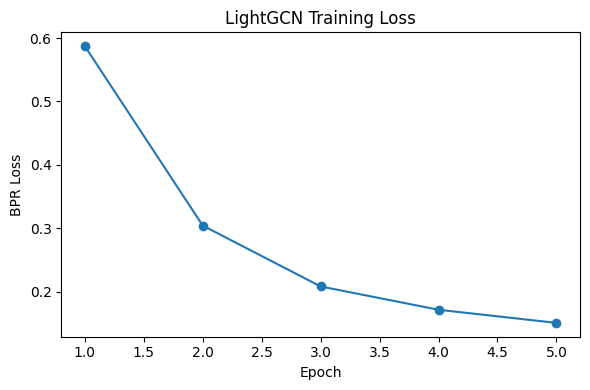

In [56]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("LightGCN Training Loss")
plt.tight_layout()

loss_fig_path = REPORTS_FIG_PATH / "lightgcn_training_loss.png"
plt.savefig(loss_fig_path, dpi=150, bbox_inches="tight")
print("Saved to:", loss_fig_path)

plt.show()

In [57]:
val_scores_by_label = pd.DataFrame({
    "probability": val_probs_lgcn,
    "label": y_val_lgcn
})

print(val_scores_by_label.groupby("label")["probability"].describe())

          count      mean       std           min       25%       50%  \
label                                                                   
0.0    344531.0  0.923840  0.134271  2.104546e-20  0.916840  0.989529   
1.0    115316.0  0.944364  0.113209  1.659512e-10  0.956894  0.995635   

            75%  max  
label                 
0.0    0.999401  1.0  
1.0    0.999782  1.0  


Saved to: reports/modeling/figures/lightgcn_validation_score_distribution.png


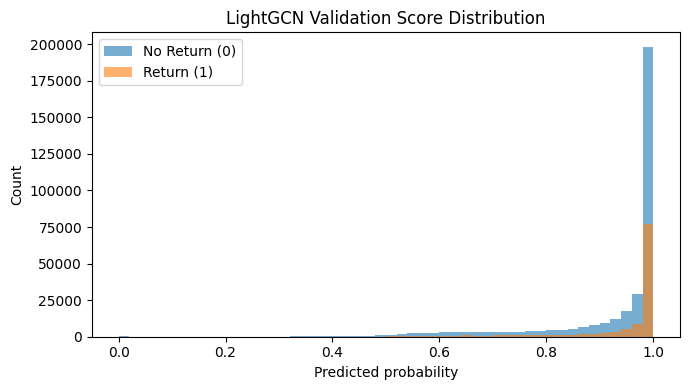

In [58]:
plt.figure(figsize=(7, 4))

plt.hist(
    val_scores_by_label[val_scores_by_label["label"] == 0]["probability"],
    bins=50,
    alpha=0.6,
    label="No Return (0)"
)

plt.hist(
    val_scores_by_label[val_scores_by_label["label"] == 1]["probability"],
    bins=50,
    alpha=0.6,
    label="Return (1)"
)

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("LightGCN Validation Score Distribution")
plt.legend()
plt.tight_layout()

score_fig_path = REPORTS_FIG_PATH / "lightgcn_validation_score_distribution.png"
plt.savefig(score_fig_path, dpi=150, bbox_inches="tight")
print("Saved to:", score_fig_path)

plt.show()

### Addressing Score Saturation in LightGCN

The LightGCN model trained with BPR loss produces highly saturated scores that are not well-suited for binary classification. Instead of directly using these scores for prediction, the learned node embeddings are treated as representations of users and streamers. These embeddings are then used as input features for a downstream supervised model (e.g., Logistic Regression or XGBoost), which is better aligned with the re-engagement prediction task.

## Extracting Node Embeddings

After training, the LightGCN model is used to generate final node embeddings for all users and streamers in the training graph.

These embeddings capture the structural relationships in the interaction graph and will be used as input features for a downstream supervised model.

In [59]:
# Extract final node embeddings
model.eval()

with torch.no_grad():
    final_node_embeddings = model(edge_index)

print("Node embedding shape:", final_node_embeddings.shape)

Node embedding shape: torch.Size([195745, 64])


## Constructing Pair-Level Graph Features

For each (user, streamer) pair in the validation and test sets, graph-based features are constructed from the learned embeddings.

The following representations are used:

- user embedding
- streamer embedding
- dot product (interaction strength)

These features will be used as inputs to a downstream classifier.

In [60]:
def build_graph_features(edge_label_index, node_embeddings):
    user_idx = edge_label_index[0]
    streamer_idx = edge_label_index[1]

    user_emb = node_embeddings[user_idx]
    streamer_emb = node_embeddings[streamer_idx]

    dot_product = (user_emb * streamer_emb).sum(dim=1, keepdim=True)

    # Concatenate features
    features = torch.cat([user_emb, streamer_emb, dot_product], dim=1)

    return features.cpu().numpy()

In [61]:
# Build validation graph features
X_val_graph = build_graph_features(
    val_edge_label_index,
    final_node_embeddings
)

y_val_graph = val_edge_label.numpy()

print("Validation graph feature shape:", X_val_graph.shape)

Validation graph feature shape: (459847, 129)


In [62]:
# Build test graph features
X_test_graph = build_graph_features(
    test_edge_label_index,
    final_node_embeddings
)

y_test_graph = test_edge_label.numpy()

print("Test graph feature shape:", X_test_graph.shape)

Test graph feature shape: (403830, 129)


In [63]:
train_graph_df, train_edge_label_index, train_edge_label = prepare_prediction_edges(
    train_df,
    "Train"
)

X_train_graph = build_graph_features(
    train_edge_label_index,
    final_node_embeddings
)

y_train_graph = train_edge_label.numpy()

print("Train graph feature shape:", X_train_graph.shape)
print("Train labels shape:", y_train_graph.shape)

Train original rows: 1373160
Train usable rows: 1373160
Train excluded rows: 0
Train usable rate: 1.0
Train graph feature shape: (1373160, 129)
Train labels shape: (1373160,)


## Graph-Only Supervised Baseline

The LightGCN embeddings are used as input features to a supervised classifier.

This model evaluates how much predictive signal is captured by the graph representations alone, without incorporating the original tabular behavioral features.

Logistic Regression is used as a baseline classifier to ensure a direct comparison with Phase 5A.

A standard scaler is applied before Logistic Regression because embedding dimensions may differ in scale. The maximum number of iterations is increased to ensure convergence.

In [64]:
lr_graph_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=500,
        solver="lbfgs",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

lr_graph_pipeline.fit(X_train_graph, y_train_graph)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=500, n_jobs=-1, random_state=42))])

In [65]:
# Validation predictions
val_probs_lr_graph = lr_graph_pipeline.predict_proba(X_val_graph)[:, 1]

val_result_05_lr_graph = evaluate_threshold(y_val_graph, val_probs_lr_graph, 0.5)
val_result_best_lr_graph = find_best_threshold(y_val_graph, val_probs_lr_graph)

print("Validation @ 0.5 (Graph LR):")
for k, v in val_result_05_lr_graph.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (Graph LR):")
for k, v in val_result_best_lr_graph.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5 (Graph LR):
threshold: 0.5000
roc_auc: 0.5801
pr_auc: 0.3061
f1: 0.0027
precision: 0.3019
recall: 0.0014

Best validation threshold (Graph LR):
threshold: 0.1800
roc_auc: 0.5801
pr_auc: 0.3061
f1: 0.4069
precision: 0.2696
recall: 0.8290


## Hybrid Feature Construction

The hybrid model combines two sources of information:

- leakage-safe tabular features from Phase 4
- graph-based embedding features extracted from LightGCN

This setup tests whether learned graph representations provide additional predictive value beyond the engineered behavioral, temporal, and structural features used in traditional models.

In [ ]:
# Load Phase 4 feature dataset
FEATURE_DATA_PATH = Path("../data_processed/model_dataset_100k_3day_features_v1.csv")

features_df = pd.read_csv(FEATURE_DATA_PATH)

print("Feature dataset shape:", features_df.shape)
print("Columns:", features_df.columns.tolist())

Feature dataset shape: (2380571, 30)
Columns: ['user_id', 'streamer_name', 'prediction_time', 'user_past_sessions', 'user_total_watch_time', 'user_avg_session_duration', 'user_recency', 'user_has_history', 'streamer_past_sessions', 'streamer_total_watch_time', 'streamer_avg_session_duration', 'streamer_recency', 'streamer_has_history', 'pair_past_sessions', 'pair_total_watch_time', 'pair_avg_session_duration', 'pair_recency', 'pair_has_history', 'time_sin_day', 'time_cos_day', 'time_sin_week', 'time_cos_week', 'user_unique_streamers', 'streamer_unique_users', 'user_repeat_ratio', 'streamer_repeat_audience_ratio', 'pair_watch_share_user', 'pair_watch_share_streamer', 'label', 'segment']


In [68]:
TABULAR_FEATURE_COLUMNS = [
    "user_past_sessions",
    "user_total_watch_time",
    "user_avg_session_duration",
    "user_recency",
    "user_has_history",

    "streamer_past_sessions",
    "streamer_total_watch_time",
    "streamer_avg_session_duration",
    "streamer_recency",
    "streamer_has_history",

    "pair_past_sessions",
    "pair_total_watch_time",
    "pair_avg_session_duration",
    "pair_recency",
    "pair_has_history",

    "time_sin_day",
    "time_cos_day",
    "time_sin_week",
    "time_cos_week",

    "user_unique_streamers",
    "streamer_unique_users",
    "user_repeat_ratio",
    "streamer_repeat_audience_ratio",
    "pair_watch_share_user",
    "pair_watch_share_streamer",
]

In [69]:
# Keys used to align graph-usable rows with the tabular feature dataset
MERGE_KEYS = ["user_id", "streamer_name", "prediction_time", "label", "segment"]

# Check whether merge keys are unique in the feature dataset
duplicate_keys = features_df.duplicated(subset=MERGE_KEYS).sum()
print("Duplicate merge keys in feature dataset:", duplicate_keys)

Duplicate merge keys in feature dataset: 0


In [70]:
def attach_tabular_features(graph_df, features_df):
    merged = graph_df[MERGE_KEYS].merge(
        features_df[MERGE_KEYS + TABULAR_FEATURE_COLUMNS],
        on=MERGE_KEYS,
        how="left"
    )

    print("Input graph rows:", len(graph_df))
    print("Merged rows:", len(merged))
    print("Missing tabular values:", merged[TABULAR_FEATURE_COLUMNS].isnull().sum().sum())

    return merged


train_hybrid_df = attach_tabular_features(train_graph_df, features_df)
val_hybrid_df = attach_tabular_features(val_graph_df, features_df)
test_hybrid_df = attach_tabular_features(test_graph_df, features_df)

Input graph rows: 1373160
Merged rows: 1373160
Missing tabular values: 1060400
Input graph rows: 459847
Merged rows: 459847
Missing tabular values: 178127
Input graph rows: 403830
Merged rows: 403830
Missing tabular values: 142503


In [71]:
X_train_tabular = train_hybrid_df[TABULAR_FEATURE_COLUMNS].values
X_val_tabular = val_hybrid_df[TABULAR_FEATURE_COLUMNS].values
X_test_tabular = test_hybrid_df[TABULAR_FEATURE_COLUMNS].values

print("Train tabular shape:", X_train_tabular.shape)
print("Validation tabular shape:", X_val_tabular.shape)
print("Test tabular shape:", X_test_tabular.shape)

Train tabular shape: (1373160, 25)
Validation tabular shape: (459847, 25)
Test tabular shape: (403830, 25)


In [72]:
# Combine tabular features with LightGCN graph embedding features
X_train_hybrid = np.hstack([X_train_tabular, X_train_graph])
X_val_hybrid = np.hstack([X_val_tabular, X_val_graph])
X_test_hybrid = np.hstack([X_test_tabular, X_test_graph])

y_train_hybrid = y_train_graph
y_val_hybrid = y_val_graph
y_test_hybrid = y_test_graph

print("Train hybrid shape:", X_train_hybrid.shape)
print("Validation hybrid shape:", X_val_hybrid.shape)
print("Test hybrid shape:", X_test_hybrid.shape)

Train hybrid shape: (1373160, 154)
Validation hybrid shape: (459847, 154)
Test hybrid shape: (403830, 154)


## Hybrid Model: Tabular + Graph Features

The hybrid model combines engineered tabular features from Phase 4 with graph-based embedding features learned by LightGCN.

This setup evaluates whether structural information from the interaction graph provides additional predictive power beyond traditional behavioral features.

In [73]:
xgb_hybrid = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_hybrid.fit(X_train_hybrid, y_train_hybrid)

Pipeline(steps=[('imputer', SimpleImputer(fill_value=-1, strategy='constant')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [74]:
val_probs_xgb_hybrid = xgb_hybrid.predict_proba(X_val_hybrid)[:, 1]

val_result_05_xgb_hybrid = evaluate_threshold(y_val_hybrid, val_probs_xgb_hybrid, 0.5)
val_result_best_xgb_hybrid = find_best_threshold(y_val_hybrid, val_probs_xgb_hybrid)

print("Validation @ 0.5 (Hybrid XGB):")
for k, v in val_result_05_xgb_hybrid.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (Hybrid XGB):")
for k, v in val_result_best_xgb_hybrid.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5 (Hybrid XGB):
threshold: 0.5000
roc_auc: 0.7099
pr_auc: 0.4597
f1: 0.2830
precision: 0.5710
recall: 0.1881

Best validation threshold (Hybrid XGB):
threshold: 0.2300
roc_auc: 0.7099
pr_auc: 0.4597
f1: 0.4906
precision: 0.3855
recall: 0.6746


### Hybrid Model Result

The hybrid model achieves a small improvement over the tabular-only baseline, increasing ROC-AUC from approximately 0.705 to 0.7099.

This indicates that graph-based embeddings provide additional predictive signal, but the improvement is limited. Most of the predictive power is already captured by the engineered behavioral and temporal features.

## Final Evaluation on Test Set

The hybrid model is evaluated on the test set using the threshold selected on the validation set.

No further tuning is performed at this stage. This ensures a fair and leakage-free final evaluation.

In [75]:
# Use validation-selected threshold
best_threshold = val_result_best_xgb_hybrid["threshold"]
print("Using threshold:", best_threshold)

Using threshold: 0.23


In [76]:
# Test predictions
test_probs_xgb_hybrid = xgb_hybrid.predict_proba(X_test_hybrid)[:, 1]

test_result_xgb_hybrid = evaluate_threshold(
    y_test_hybrid,
    test_probs_xgb_hybrid,
    best_threshold
)

print("Test results (Hybrid XGB):")
for k, v in test_result_xgb_hybrid.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Test results (Hybrid XGB):
threshold: 0.2300
roc_auc: 0.6978
pr_auc: 0.4479
f1: 0.4847
precision: 0.3771
recall: 0.6783


### Final Test Result

The hybrid model achieves a test ROC-AUC of 0.6978, which is comparable to the tabular-only baseline. Although slight improvements were observed on the validation set, these gains do not persist on the test set.

This indicates that graph-based embeddings provide limited additional predictive value beyond the engineered behavioral and temporal features. The results suggest that user re-engagement is primarily driven by individual interaction history rather than broader network structure.